# 1 Load Data

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("../../Data/student_performance_data.csv")
df.drop(columns=['overall_score','student_id'], inplace=True)
df

,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,grade
0,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,D
1,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,D
2,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,B
3,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,C
4,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,C
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,6.86,59.65,60.41,39.51,66.43,44.97,Yes,Yes,High School,8.56,C
9996,Male,2.60,83.62,62.45,48.96,81.40,45.11,Yes,Yes,Bachelor,4.21,C
9997,Female,1.46,95.40,67.08,51.51,87.58,65.49,Yes,No,Bachelor,4.72,B
9998,Female,7.15,78.24,97.73,46.51,75.49,61.21,No,No,Bachelor,5.28,B


In [2]:
df['grade'].value_counts()

grade
C    5073
B    2704
D    2008
A     154
F      61
Name: count, dtype: int64

In [3]:
df = df[df['grade'].isin(['C','B'])]

In [4]:
df.columns

Index(['gender', 'study_hours_per_day', 'attendance_percentage',
       'assignment_score', 'midterm_score', 'final_exam_score',
       'participation_score', 'internet_access', 'extra_classes',
       'parent_education', 'sleep_hours', 'grade'],
      dtype='str')

# 2. Data Preprocess

##### ohe -> 'gender'
##### ordinal -> 'parent_education'
##### Label -> 'internet_access', 'extra_classes'
##### scaling_transform -> 'study_hours_per_day', 'attendance_percentage','assignment_score', 'participation_score',midterm_score', 'final_exam_score', 'sleep_hours'



In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, PowerTransformer

scaling_transform = Pipeline([
    ("scl", StandardScaler()),
    ('power', PowerTransformer())
])

preprocessor = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['gender']),
    ("ord", OrdinalEncoder(categories=[['High School','Bachelor','Master','PhD']]), ['parent_education']),
    ("ord_bin", OrdinalEncoder(), ['internet_access', 'extra_classes']),
    ("scaling_transform", scaling_transform, ['study_hours_per_day', 'attendance_percentage','assignment_score', 'midterm_score', 'final_exam_score','participation_score', 'sleep_hours'])
    
],remainder='passthrough')

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=42)

In [7]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [8]:
lb = LabelEncoder()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

In [9]:
X_train

array([[ 1.        ,  0.        ,  2.        , ...,  1.55723615,
        -0.75892707, -0.89485911],
       [ 0.        ,  1.        ,  0.        , ...,  0.72436296,
        -0.29935487,  0.29754975],
       [ 1.        ,  0.        ,  0.        , ...,  1.39260359,
         1.18104473, -0.11537298],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -1.84484122,
         1.65800829,  0.10459476],
       [ 0.        ,  1.        ,  0.        , ..., -0.78651245,
        -0.41800821, -1.37117388],
       [ 1.        ,  0.        ,  2.        , ...,  1.00338957,
         1.44685614, -1.19442421]], shape=(6221, 12))

In [11]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# 3. Dataload

In [12]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [13]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

# 4. Build Model

In [14]:
import torch.nn as nn
class MySimplePerceptron(nn.Module):
    def __init__(self, X_train):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
            
            nn.Linear(6,3),
            nn.ReLU(),
            
            nn.Linear(3, 1),
            nn.Sigmoid()
        )
        
    def forward(self, X_train):
        return self.network(X_train)
    

# 5. Train Model

In [15]:
def train_model(learning_rate = 0.1,epochs = 100):
    model = MySimplePerceptron(X_train)
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    loss_function = nn.BCELoss()
    
    losses = []
    
    for epoch in range(epochs):
        for batch_features, batch_labels in train_dataloader:
        
            # move to gpu
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            
            # forward propagation
            y_pred = model.forward(batch_features)
            
            # loss calculate
            loss = loss_function(y_pred, batch_labels.view(-1,1))
            
            # reinitialize gradient
            optimizer.zero_grad()
            
            # backpropagation
            loss.backward()
            
            # update weight and bias
            optimizer.step()
            
        losses.append(loss.item())
        print(f"Epoch: {epoch+1}, Loss: {loss.item()}")
        
    return model, losses

In [16]:
epochs = 40
model, losses = train_model(epochs=epochs, learning_rate=0.01)

Epoch: 1, Loss: 0.04361524060368538
Epoch: 2, Loss: 0.009809218347072601
Epoch: 3, Loss: 0.07491429150104523
Epoch: 4, Loss: 0.005680582020431757
Epoch: 5, Loss: 0.014776217751204967
Epoch: 6, Loss: 0.013017459772527218
Epoch: 7, Loss: 0.016952797770500183
Epoch: 8, Loss: 0.11877181380987167
Epoch: 9, Loss: 0.05601360276341438
Epoch: 10, Loss: 0.04176780581474304
Epoch: 11, Loss: 4.998970325686969e-06
Epoch: 12, Loss: 0.040642883628606796
Epoch: 13, Loss: 0.0019149312283843756
Epoch: 14, Loss: 7.088819256750867e-05
Epoch: 15, Loss: 0.017811764031648636
Epoch: 16, Loss: 0.020457109436392784
Epoch: 17, Loss: 5.710469849873334e-05
Epoch: 18, Loss: 0.006042067427188158
Epoch: 19, Loss: 5.84136500947352e-07
Epoch: 20, Loss: 0.0026372107677161694
Epoch: 21, Loss: 8.103522304736543e-06
Epoch: 22, Loss: 0.010305517353117466
Epoch: 23, Loss: 0.0016819017473608255
Epoch: 24, Loss: 2.3195689209387638e-05
Epoch: 25, Loss: 0.010786586441099644
Epoch: 26, Loss: 0.0004186772566754371
Epoch: 27, Loss:

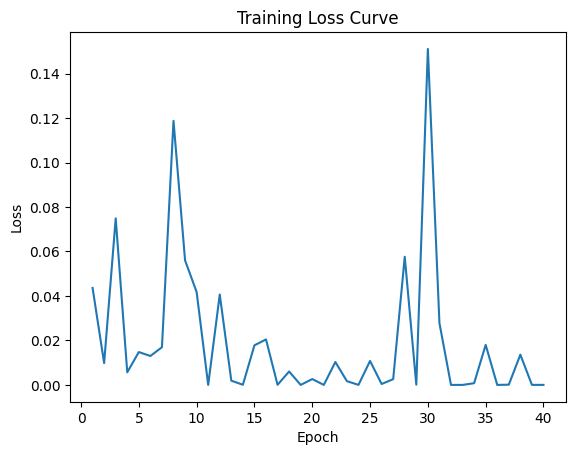

In [17]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

# 6. Evaluate Model

In [18]:
def evaluate_model(threshold=0.5):
    model.eval()
    train_accuracy_list = []
    for batch_features, batch_labels in train_dataloader:
        with torch.no_grad():  
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            y_pred = model.forward(batch_features)
            y_pred = (y_pred > threshold).float()
            
            batch_accuracy = (batch_labels == y_pred).float().mean().item()
            train_accuracy_list.append(batch_accuracy)
    train_accuracy = sum(train_accuracy_list)/len(train_accuracy_list)
    
    test_accuracy_list = []
    for batch_features, batch_labels in test_dataloader:
        with torch.no_grad():
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            y_pred = model.forward(batch_features)
            y_pred = (y_pred > threshold).float()
            
            batch_accuracy = (batch_labels == y_pred).float().mean().item()
            test_accuracy_list.append(batch_accuracy)
    test_accuracy = sum(test_accuracy_list)/len(test_accuracy_list)
    
    return {
        "Train Accuracy ":train_accuracy, 
        "Test Accuracy ":test_accuracy
    }

In [19]:
evaluate_model(threshold=0.5)

{'Train Accuracy ': 0.5471742426862523, 'Test Accuracy ': 0.5578414058685303}